In [5]:
import os

In [6]:
%pwd

'c:\\Users\\LENOVO\\Fraud-Transaction-Detection\\notebooks'

In [7]:
os.chdir("../")

In [8]:
%pwd

'c:\\Users\\LENOVO\\Fraud-Transaction-Detection'

In [9]:
# 📦 Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [10]:
# 📂 Step 2: Load predictions
df = pd.read_csv('results/predictions.csv')
df.head()


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,PREDICTED_FRAUD,FRAUD_PROBABILITY
0,1696864,2018-09-25 00:00:26,3155,6800,80.89,15292826,177,0,0,0,0.08
1,1696865,2018-09-25 00:00:42,2320,2988,118.10,15292842,177,0,0,0,0.00
2,1696866,2018-09-25 00:00:57,4699,5666,122.72,15292857,177,0,0,0,0.45
3,1696867,2018-09-25 00:01:29,348,5982,96.84,15292889,177,0,0,0,0.00
4,1696868,2018-09-25 00:02:22,721,1597,100.87,15292942,177,0,0,0,0.12


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11668\3359977825.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PREDICTED_FRAUD', data=df, palette='coolwarm')


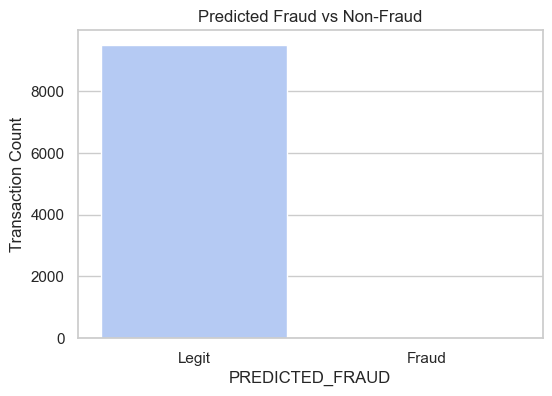

In [11]:
# 📊 Step 3: Fraud vs Non-Fraud Count
plt.figure(figsize=(6, 4))
sns.countplot(x='PREDICTED_FRAUD', data=df, palette='coolwarm')
plt.title("Predicted Fraud vs Non-Fraud")
plt.xticks([0, 1], ['Legit', 'Fraud'])
plt.ylabel("Transaction Count")
plt.show()

In [12]:
# 🔝 Step 4: Top 10 Most Suspicious Transactions
top_frauds = df.sort_values(by='FRAUD_PROBABILITY', ascending=False).head(10)
top_frauds[['TRANSACTION_ID', 'TX_AMOUNT', 'FRAUD_PROBABILITY']]

,TRANSACTION_ID,TX_AMOUNT,FRAUD_PROBABILITY
4610,1701474,41.00,0.99
4607,1701471,26.81,0.99
2401,1699265,0.92,0.98
6697,1703561,19.06,0.98
6279,1703143,41.50,0.98
2528,1699392,22.65,0.98
5619,1702483,7.47,0.97
4606,1701470,22.22,0.97
6731,1703595,126.33,0.97
7866,1704730,43.80,0.97


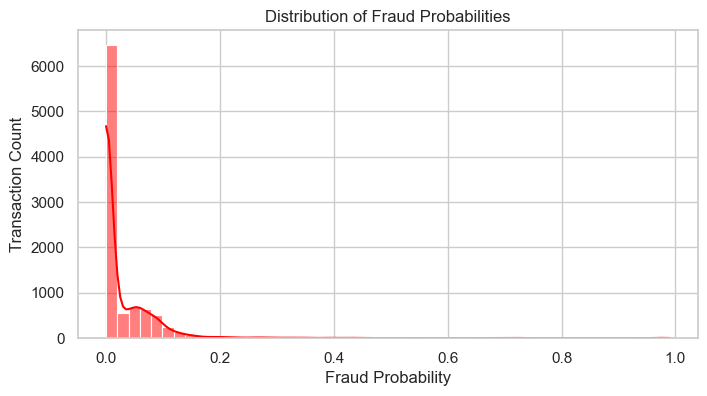

In [13]:
# 📈 Step 5: Fraud Probability Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['FRAUD_PROBABILITY'], bins=50, kde=True, color='red')
plt.title("Distribution of Fraud Probabilities")
plt.xlabel("Fraud Probability")
plt.ylabel("Transaction Count")
plt.show()


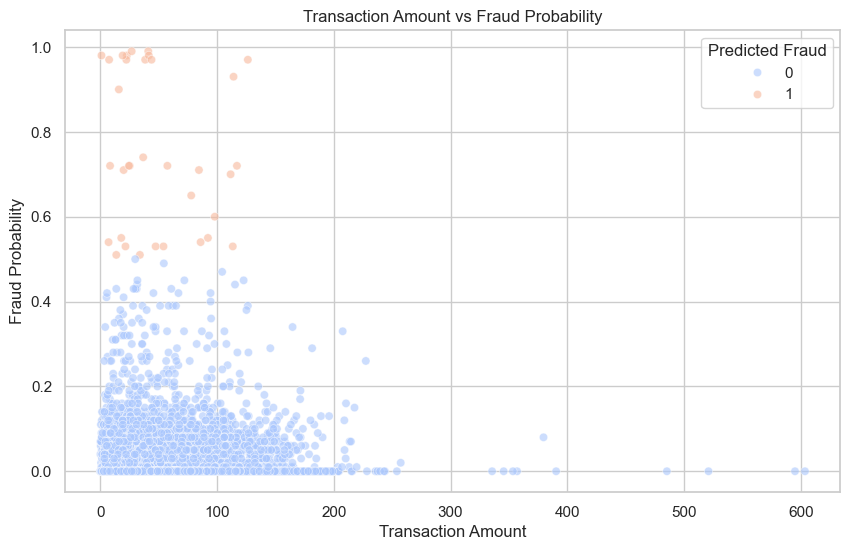

In [14]:
# 🔍 Step 6: Amount vs Fraud Probability
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TX_AMOUNT', y='FRAUD_PROBABILITY', hue='PREDICTED_FRAUD', data=df, alpha=0.6, palette='coolwarm')
plt.title("Transaction Amount vs Fraud Probability")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Probability")
plt.legend(title='Predicted Fraud')
plt.show()

In [15]:
# 📂 Load predictions
df = pd.read_csv('results/predictions.csv')

# 🔍 Filter only fraud predictions
fraud_df = df[df['PREDICTED_FRAUD'] == 1]

# 📊 Preview top frauds
fraud_df

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,PREDICTED_FRAUD,FRAUD_PROBABILITY
404,1697268,2018-09-25 03:09:58,2541,8790,15.80,15304198,177,0,0,1,0.90
1325,1698189,2018-09-25 06:13:16,1021,7432,36.66,15315196,177,0,0,1,0.74
1676,1698540,2018-09-25 07:01:40,3719,5614,114.08,15318100,177,0,0,1,0.93
2259,1699124,2018-09-25 08:09:10,4046,342,19.90,15322150,177,0,0,1,0.71
2401,1699265,2018-09-25 08:22:59,2549,2558,0.92,15322979,177,0,0,1,0.98
2402,1699266,2018-09-25 08:22:59,2018,6508,84.44,15322979,177,0,0,1,0.71
2415,1699279,2018-09-25 08:23:55,3001,2303,113.43,15323035,177,0,0,1,0.53
2528,1699392,2018-09-25 08:36:40,1960,5151,22.65,15323800,177,0,0,1,0.98
3206,1700070,2018-09-25 09:40:36,4521,3752,13.61,15327636,177,1,2,1,0.51
3560,1700424,2018-09-25 10:15:09,2780,1160,38.36,15329709,177,0,0,1,0.97


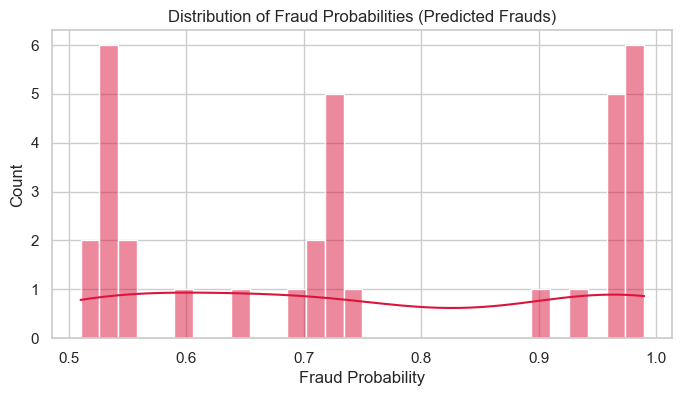

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(fraud_df['FRAUD_PROBABILITY'], bins=30, kde=True, color='crimson')
plt.title("Distribution of Fraud Probabilities (Predicted Frauds)")
plt.xlabel("Fraud Probability")
plt.ylabel("Count")
plt.show()

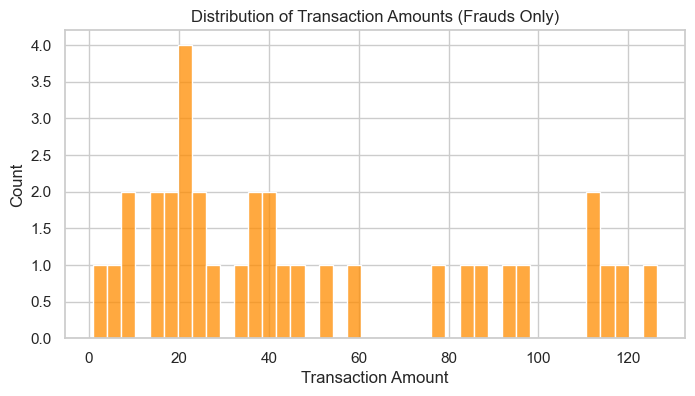

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(fraud_df['TX_AMOUNT'], bins=40, color='darkorange')
plt.title("Distribution of Transaction Amounts (Frauds Only)")
plt.xlabel("Transaction Amount")
plt.ylabel("Count")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11668\3865666334.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_frauds, x='TRANSACTION_ID', y='FRAUD_PROBABILITY', palette='Reds_r')


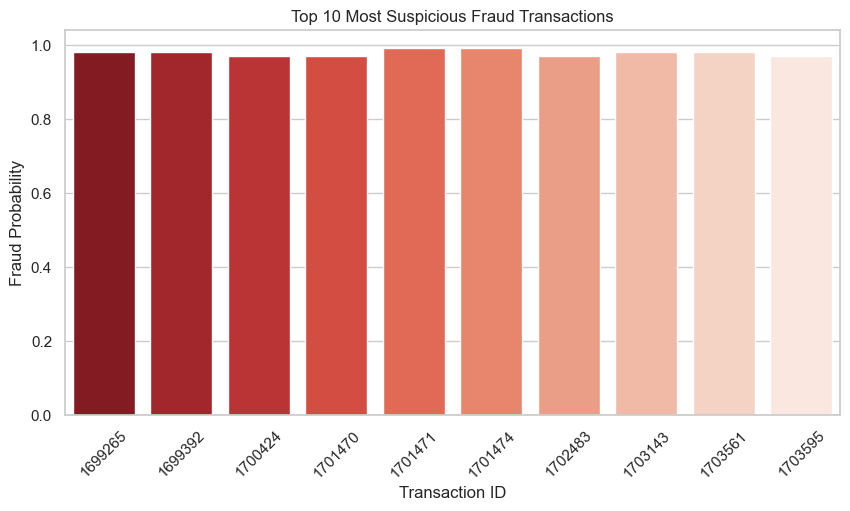

In [18]:
top_frauds = fraud_df.sort_values(by='FRAUD_PROBABILITY', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_frauds, x='TRANSACTION_ID', y='FRAUD_PROBABILITY', palette='Reds_r')
plt.xticks(rotation=45)
plt.title("Top 10 Most Suspicious Fraud Transactions")
plt.ylabel("Fraud Probability")
plt.xlabel("Transaction ID")
plt.show()

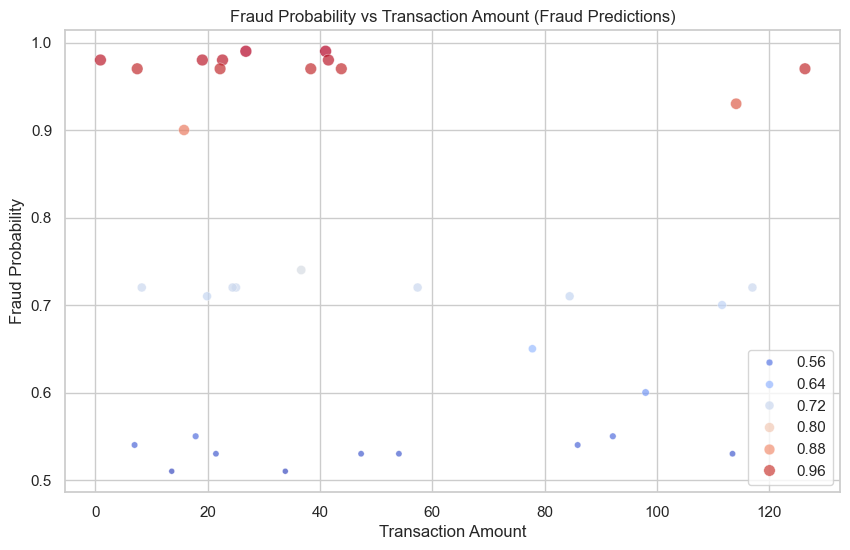

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fraud_df, x='TX_AMOUNT', y='FRAUD_PROBABILITY', size='FRAUD_PROBABILITY', hue='FRAUD_PROBABILITY', palette='coolwarm', alpha=0.7)
plt.title("Fraud Probability vs Transaction Amount (Fraud Predictions)")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Probability")
plt.legend(loc='best')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11668\3803835020.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11668\3803835020.py:27: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\LENOVO\anaconda3\envs\fenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


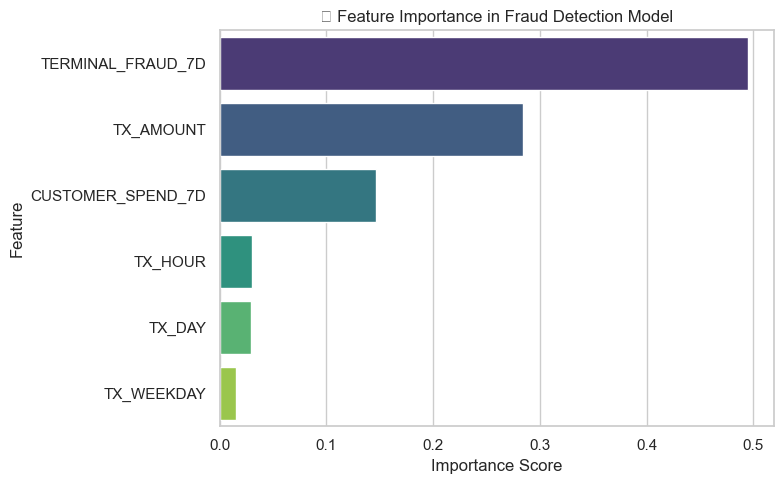

In [20]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained model
model = joblib.load('models/fraud_model.pkl')

# Define the feature names used during training
features = ['TX_AMOUNT', 'TX_HOUR', 'TX_DAY', 'TX_WEEKDAY', 'TERMINAL_FRAUD_7D', 'CUSTOMER_SPEND_7D']

# Extract feature importances
importances = model.feature_importances_

# Create a DataFrame for plotting
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("🔍 Feature Importance in Fraud Detection Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()
